# Part I - Prosper Loan Dataset
## by S Sarveshwar


## Preliminary Wrangling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('whitegrid')


In [2]:
df = pd.read_csv('prosperLoanData.csv')
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

,ListingNumber,Term,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperScore,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
count,1.139370e+05,113937.000000,113912.000000,113937.000000,113937.000000,84853.000000,84853.000000,84853.000000,84853.000000,84853.000000,...,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000
mean,6.278857e+05,40.830248,0.218828,0.192764,0.182701,0.168661,0.080306,0.096068,4.072243,5.950067,...,-54.725641,-14.242698,700.446342,681.420499,25.142686,0.998584,0.048027,0.023460,16.550751,80.475228
std,3.280762e+05,10.436212,0.080364,0.074818,0.074516,0.068467,0.046764,0.030403,1.673227,2.376501,...,60.675425,109.232758,2388.513831,2357.167068,275.657937,0.017919,0.332353,0.232412,294.545422,103.239020
min,4.000000e+00,12.000000,0.006530,0.000000,-0.010000,-0.182700,0.004900,-0.182700,1.000000,1.000000,...,-664.870000,-9274.750000,-94.200000,-954.550000,0.000000,0.700000,0.000000,0.000000,0.000000,1.000000
25%,4.009190e+05,36.000000,0.156290,0.134000,0.124200,0.115670,0.042400,0.074080,3.000000,4.000000,...,-73.180000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000
50%,6.005540e+05,36.000000,0.209760,0.184000,0.173000,0.161500,0.072400,0.091700,4.000000,6.000000,...,-34.440000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,44.000000
75%,8.926340e+05,36.000000,0.283810,0.250000,0.240000,0.224300,0.112000,0.116600,5.000000,8.000000,...,-13.920000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,115.000000
max,1.255725e+06,60.000000,0.512290,0.497500,0.492500,0.319900,0.366000,0.283700,7.000000,11.000000,...,32.060000,0.000000,25000.000000,25000.000000,21117.900000,1.012500,39.000000,33.000000,25000.000000,1189.000000


In [4]:
df.isnull().sum()

ListingKey                         0
ListingNumber                      0
ListingCreationDate                0
CreditGrade                    84984
Term                               0
                               ...  
PercentFunded                      0
Recommendations                    0
InvestmentFromFriendsCount         0
InvestmentFromFriendsAmount        0
Investors                          0
Length: 81, dtype: int64

In [5]:
df.sample(10)

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
35423,BC6234226312131416C8DA3,348093,2008-06-10 13:12:13.567000000,B,36,Completed,2010-04-08 00:00:00,0.15882,0.1445,0.1345,...,-178.91,0.0,0.00,0.00,0.0,1.0,0,0,0.0,241
7985,99ED34789489579407D3954,451567,2010-03-23 19:23:05.040000000,NaN,36,Completed,2012-05-10 00:00:00,0.26282,0.2399,0.2299,...,-73.46,0.0,0.00,0.00,0.0,1.0,2,0,0.0,204
86362,EEF2359117967217506FDDD,945349,2013-10-10 08:26:35.750000000,NaN,60,Current,NaN,0.28078,0.2549,0.2449,...,-16.92,0.0,0.00,0.00,0.0,1.0,0,0,0.0,136
78863,1B2B3544420119669E13F46,574933,2012-04-03 08:29:54.537000000,NaN,12,Completed,2013-03-18 00:00:00,0.26584,0.1672,0.1572,...,-10.17,0.0,0.00,0.00,0.0,1.0,0,0,0.0,50
48804,3B21357593798573840A41E,750980,2013-04-12 11:06:31.877000000,NaN,36,Current,NaN,0.29537,0.2566,0.2466,...,-33.61,0.0,0.00,0.00,0.0,1.0,0,0,0.0,82
8576,38223600968175199FF2648,1176567,2014-01-31 14:26:22.843000000,NaN,36,Current,NaN,0.22773,0.1905,0.1805,...,0.00,0.0,0.00,0.00,0.0,1.0,0,0,0.0,1
34564,322C355516872300479F684,624794,2012-08-15 16:28:03.747000000,NaN,36,Current,NaN,0.19645,0.1599,0.1499,...,-213.74,0.0,0.00,0.00,0.0,1.0,0,0,0.0,282
112712,E2CD341127391966656EBA3,266982,2008-01-17 10:03:22.690000000,D,36,Chargedoff,2009-09-24 00:00:00,0.25517,0.2400,0.2300,...,-30.07,0.0,1894.66,1894.66,0.0,1.0,0,0,0.0,27
82096,6C4F341157596208741FEEA,275695,2008-02-04 12:40:16.957000000,A,36,Completed,2011-01-31 00:00:00,0.17445,0.1600,0.1500,...,-306.57,0.0,0.00,0.00,0.0,1.0,1,0,0.0,448
90139,C3F13419756001014EAC3A6,319283,2008-04-27 15:20:12.330000000,D,36,Completed,2011-05-09 00:00:00,0.17677,0.1550,0.1450,...,-82.82,0.0,0.00,0.00,0.0,1.0,0,0,0.0,118


In [6]:
loan_df = df[['BorrowerAPR',
              'ProsperScore',
              'LoanOriginalAmount',
              'EmploymentStatus',
              'StatedMonthlyIncome',
              'CreditScoreRangeLower',
              'CreditScoreRangeUpper',
              'IncomeRange',
              'LoanStatus',
              'Term']]

In [7]:
loan_df = loan_df.dropna()

In [8]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84853 entries, 1 to 113936
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BorrowerAPR            84853 non-null  float64
 1   ProsperScore           84853 non-null  float64
 2   LoanOriginalAmount     84853 non-null  int64  
 3   EmploymentStatus       84853 non-null  object 
 4   StatedMonthlyIncome    84853 non-null  float64
 5   CreditScoreRangeLower  84853 non-null  float64
 6   CreditScoreRangeUpper  84853 non-null  float64
 7   IncomeRange            84853 non-null  object 
 8   LoanStatus             84853 non-null  object 
 9   Term                   84853 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 7.1+ MB


In [9]:
loan_df.describe()

,BorrowerAPR,ProsperScore,LoanOriginalAmount,StatedMonthlyIncome,CreditScoreRangeLower,CreditScoreRangeUpper,Term
count,84853.000000,84853.000000,84853.000000,8.485300e+04,84853.000000,84853.000000,84853.000000
mean,0.226658,5.950067,9083.440515,5.931175e+03,699.390240,718.390240,42.486135
std,0.079916,2.376501,6287.860058,8.239944e+03,47.095937,47.095937,11.640346
min,0.045830,1.000000,1000.000000,0.000000e+00,600.000000,619.000000,12.000000
25%,0.163280,4.000000,4000.000000,3.434000e+03,660.000000,679.000000,36.000000
50%,0.219450,6.000000,7500.000000,5.000000e+03,700.000000,719.000000,36.000000
75%,0.292540,8.000000,13500.000000,7.083333e+03,720.000000,739.000000,60.000000
max,0.423950,11.000000,35000.000000,1.750003e+06,880.000000,899.000000,60.000000


In [10]:
loan_df['AverageCreditScore'] = (
    loan_df['CreditScoreRangeLower'] +
    loan_df['CreditScoreRangeUpper']
) / 2

### What is the structure of your dataset?

> There are 81 columns with 113937 entries.

### What is/are the main feature(s) of interest in your dataset?

> Analysing the main causes of default on credit.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> Borrowers' prosper rating, the loan amount and employment status may play a major role in defaulting loan.

## Univariate Exploration


## Distribution of Borrower APR

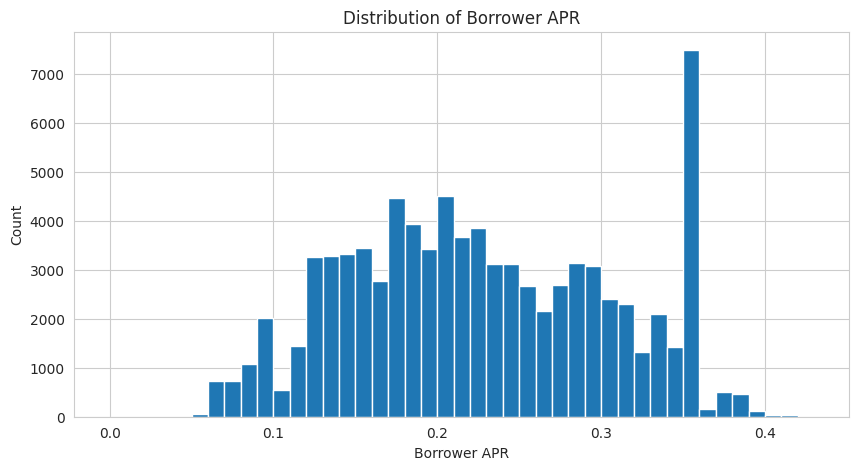

In [11]:
plt.figure(figsize=[10,5])

bins = np.arange(0, loan_df['BorrowerAPR'].max()+0.01, 0.01)

plt.hist(data=loan_df, x='BorrowerAPR', bins=bins)

plt.xlabel('Borrower APR')
plt.ylabel('Count')
plt.title('Distribution of Borrower APR');

>Most borrowers have APR between 10% and 25%

## Distribution of Loan Amount

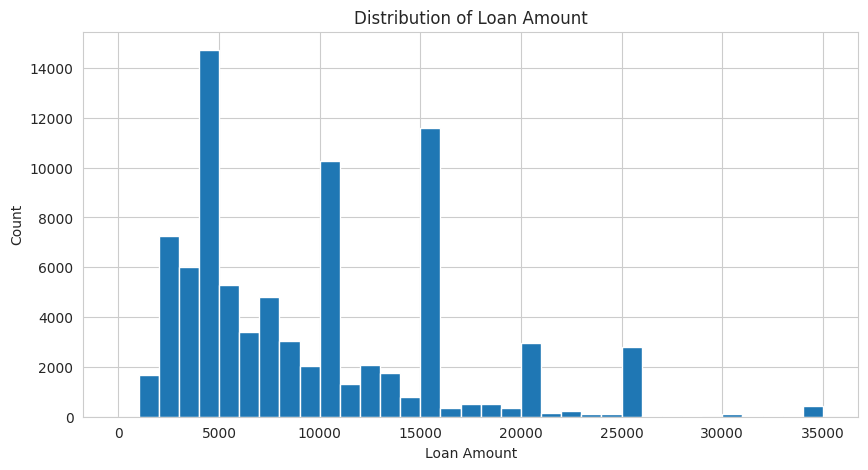

In [13]:
plt.figure(figsize=[10,5])

bins = np.arange(0, loan_df['LoanOriginalAmount'].max()+1000, 1000)

plt.hist(data=loan_df, x='LoanOriginalAmount', bins=bins)

plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.title('Distribution of Loan Amount');

>Distribution is skewed to the right.

## Employment Status

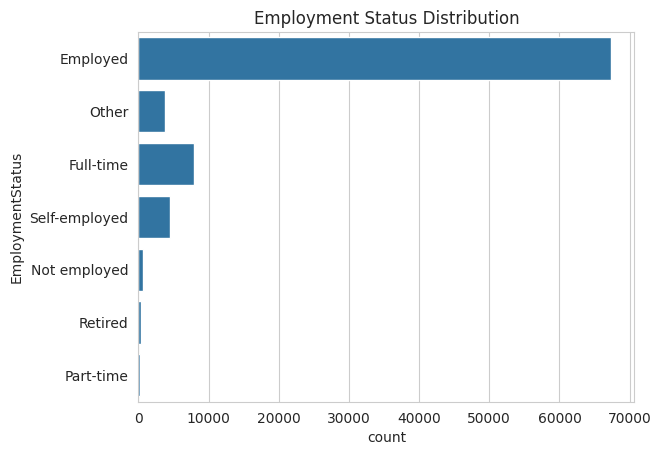

In [14]:
base_color = sns.color_palette()[0]

sns.countplot(data=loan_df,
              y='EmploymentStatus',
              color=base_color)

plt.title('Employment Status Distribution');

>Most of the borrowers are employed.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> Majority of borrowers are employed, most borrowers have APR between 10% and 25% and distribution of monthly income is skewed to the right.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> Most borrowers have APR between 10% and 25% and most of the borrowers are employed.

## Bivariate Exploration


## Loan Amount Vs Borrower APR

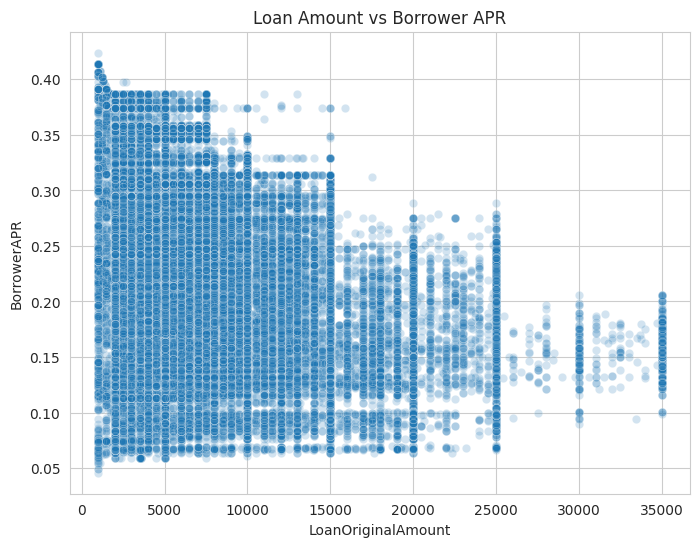

In [16]:
plt.figure(figsize=[8,6])

sns.scatterplot(data=loan_df,
                x='LoanOriginalAmount',
                y='BorrowerAPR',
                alpha=0.2)

plt.title('Loan Amount vs Borrower APR');

> Higher loan amounts genrerally have lower APR.

## Prosper Score vs Borrower APR

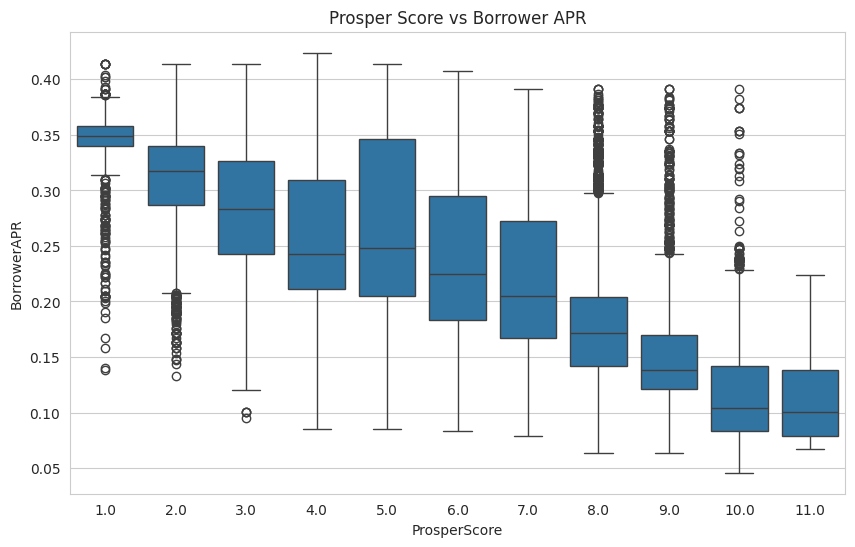

In [17]:
plt.figure(figsize=[10,6])

sns.boxplot(data=loan_df,
            x='ProsperScore',
            y='BorrowerAPR')

plt.title('Prosper Score vs Borrower APR');

> Higher Prosper Score leads to lower APR.

## Income Range Vs Borrower APR

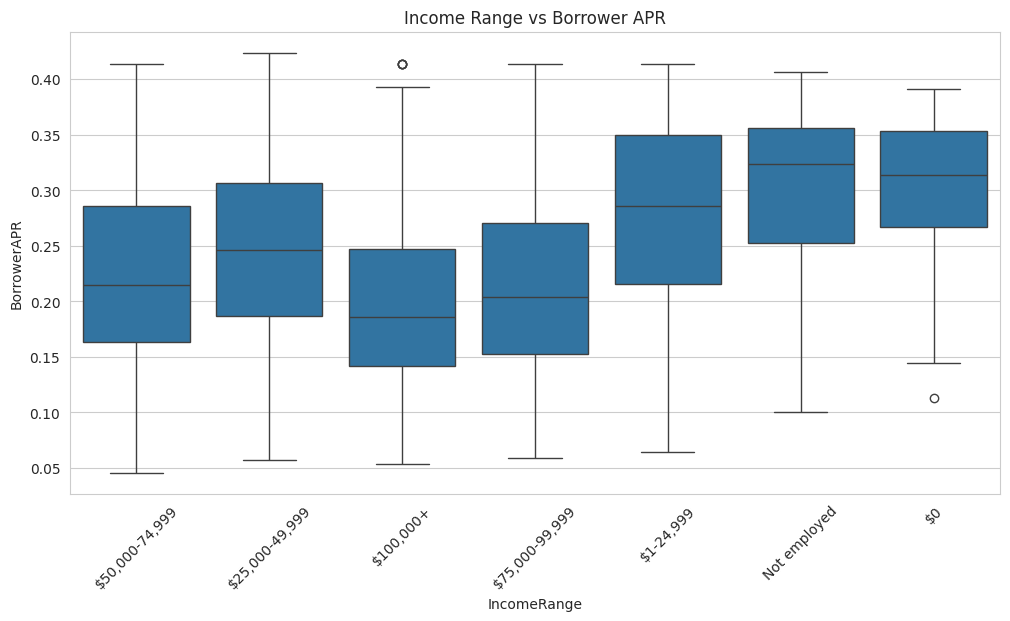

In [18]:
plt.figure(figsize=[12,6])

sns.boxplot(data=loan_df,
            x='IncomeRange',
            y='BorrowerAPR')

plt.xticks(rotation=45)

plt.title('Income Range vs Borrower APR');

>Higher-income borrowers tend to receive lower APR.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Higher loan amounts genrerally have lower APR. Higher Prosper Score leads to lower APR.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Higher-income borrowers tend to receive lower APR.

## Multivariate Exploration



## APR vs Loan Amount by Prosper Score

Text(0.5, 1.0, 'APR vs Loan Amount by Prosper Score')

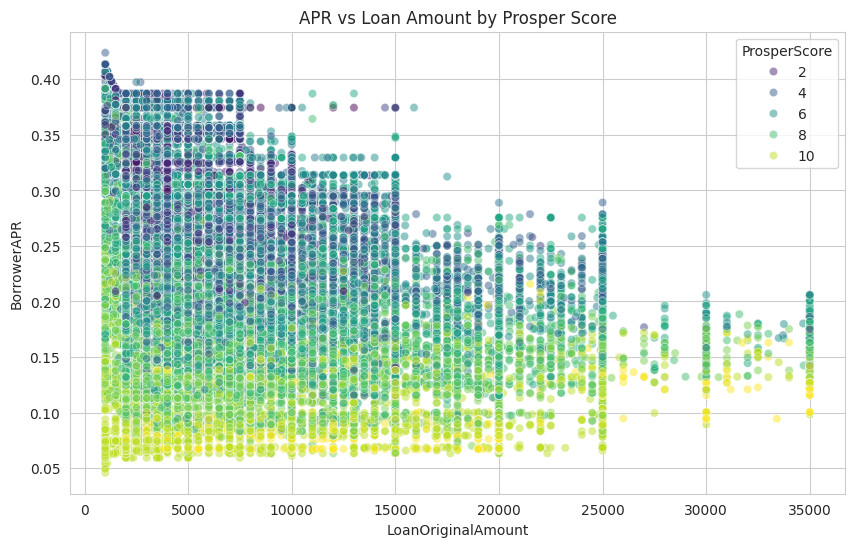

In [19]:
plt.figure(figsize=[10,6])

sns.scatterplot(data=loan_df,
                x='LoanOriginalAmount',
                y='BorrowerAPR',
                hue='ProsperScore',
                palette='viridis',
                alpha=0.5)

plt.title('APR vs Loan Amount by Prosper Score')

>Borrowers with high Prosper Scores obtain lower APR even for large loans.

>Low-score borrowers experience high APR

## Monthly Income vs APR by Prosper Score

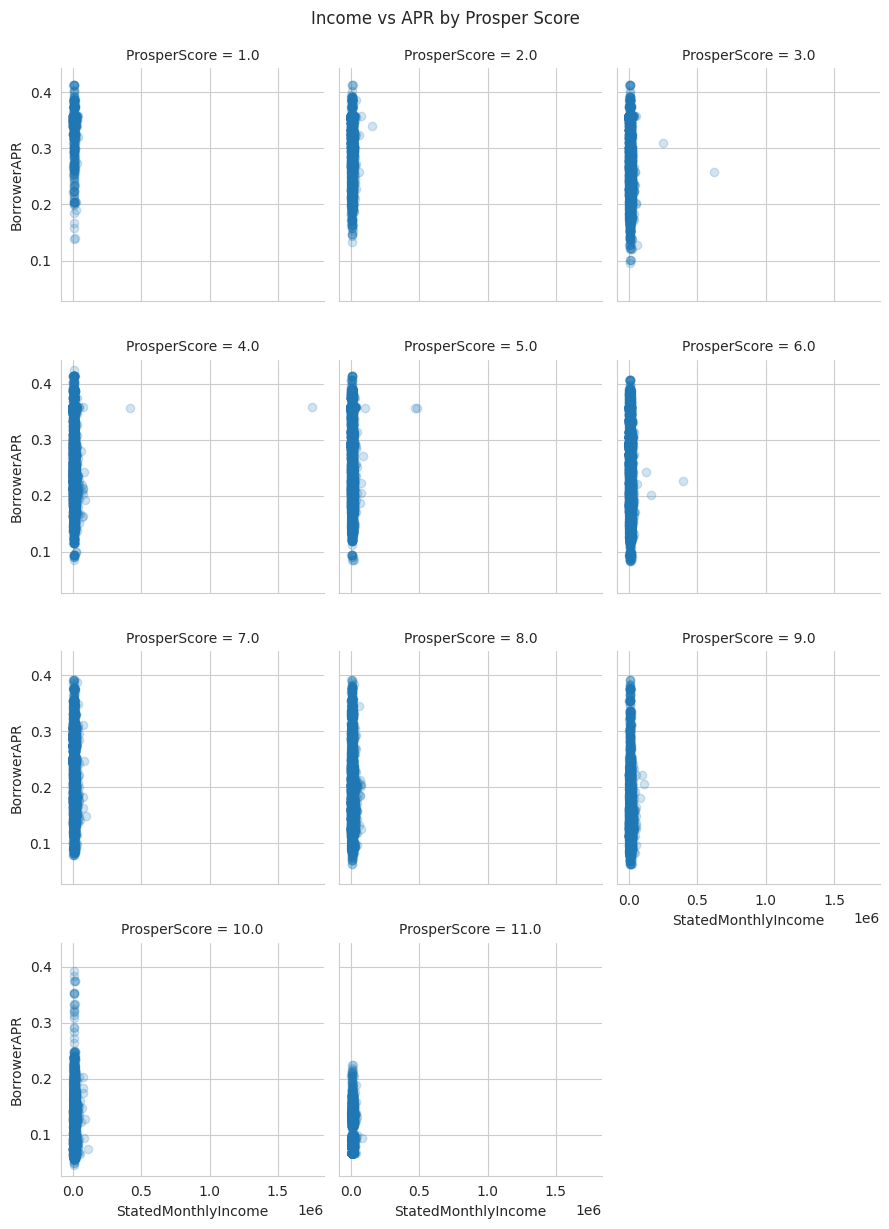

In [21]:
g = sns.FacetGrid(data=loan_df,
                  col='ProsperScore',
                  col_wrap=3)

g.map(plt.scatter,
      'StatedMonthlyIncome',
      'BorrowerAPR',
      alpha=0.2)

g.fig.suptitle('Income vs APR by Prosper Score',
               y=1.02);

>Prosper Score strongly impacts loan pricing.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> Borrower APR decreases as Prosper Score increases. Employment status and income influence loan approval and pricing. Credit score is strongly associated with lower borrower APR.

### Were there any interesting or surprising interactions between features?

> Loan amount has a negative relationship with APR.